# Extracción y registración de cromosomas

Esta etapa toma las máscaras que produce el modelo de segmentación y devuelve, para cada cromosoma, un recorte individual llevado a una orientación y un tamaño canónicos. Es el puente entre la segmentación y la clasificación: su salida es exactamente la entrada del clasificador.

Aquí se cubren dos etapas: extracción de características y registración.

## Nota: organización del código

La lógica funcional de esta etapa vive en el paquete de la interfaz (Interfaz/pipeline/extraction.py). Este notebook la importa y la documenta paso a paso, con visualizaciones intermedias.

El notebook corre de forma local con torch, sin necesidad de Detectron2, usando el modelo de segmentación exportado a TorchScript (model_ts.ts).

## Preparación e importaciones

In [3]:
import os, sys
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Localizamos la raíz del repo (la carpeta que contiene Interfaz/) subiendo desde el cwd.
REPO = os.getcwd()
while not os.path.isdir(os.path.join(REPO, "Interfaz")) and os.path.dirname(REPO) != REPO:
    REPO = os.path.dirname(REPO)
sys.path.insert(0, os.path.join(REPO, "Interfaz"))

# La lógica funcional vive en el paquete de la interfaz; acá la importamos.
from pipeline import preprocessing, segmentation, extraction
print("Repo:", REPO)

Repo: c:\Users\Santi\OneDrive\Escritorio\Final PAIByB


## Imagen de entrada

Tomamos una imagen de metafase del conjunto de test y la llevamos a 1600 x 1600, el tamaño con el que trabaja el pipeline.

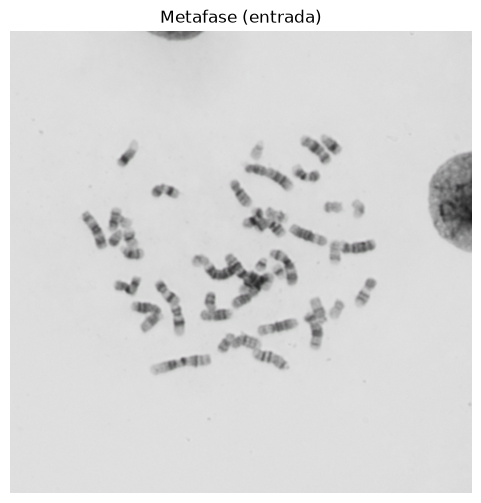

In [4]:
IMG = os.path.join(REPO, "Datasets", "Autokary2022_1600x1600", "test_labelme",
                   "211025-003C", "211025-003C_129_1_688_378_0.461.png")
image = cv2.cvtColor(cv2.imread(IMG), cv2.COLOR_BGR2RGB)
if image.shape[:2] != (segmentation.INPUT_SIZE, segmentation.INPUT_SIZE):
    image = cv2.resize(image, (segmentation.INPUT_SIZE, segmentation.INPUT_SIZE))

plt.figure(figsize=(6, 6))
plt.imshow(image); plt.axis("off"); plt.title("Metafase (entrada)")
plt.show()

## Paso previo: preprocesamiento

Los recortes de cada cromosoma se obtienen de la imagen preprocesada, no de la cruda. El preprocesamiento aplicado es el canónico (denoising con Non-Local Means y realce de contraste con CLAHE), el mismo que debe usarse al generar los recortes de entrenamiento del clasificador. Así, los recortes que ve el modelo en inferencia coinciden con los de entrenamiento.

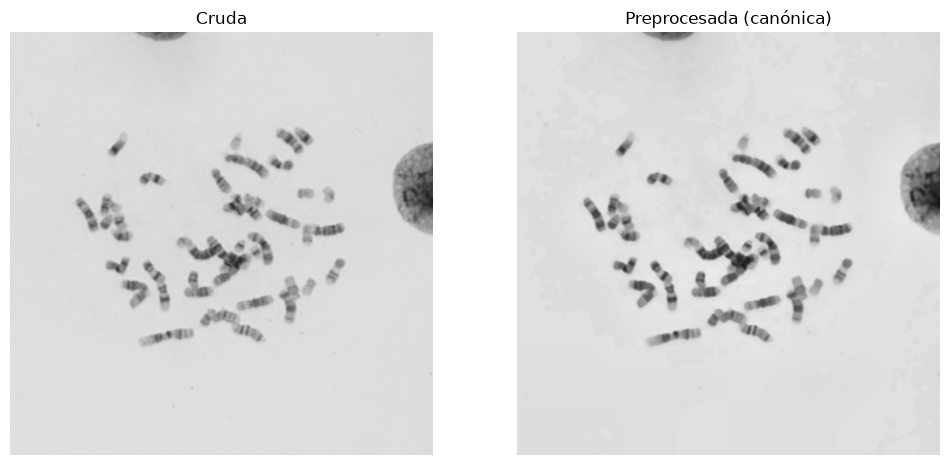

In [5]:
clf_image = preprocessing.preprocess_for_classification(image)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image); ax[0].set_title("Cruda"); ax[0].axis("off")
ax[1].imshow(clf_image); ax[1].set_title("Preprocesada (canónica)"); ax[1].axis("off")
plt.show()

## Paso 1: segmentación

Cargamos el modelo de segmentación exportado a TorchScript y obtenemos las máscaras de instancia de cada cromosoma. La segmentación se corre sobre la imagen cruda (el modelo se entrenó así); el preprocesamiento se usa recién para los recortes.

Backend: torchscript


c:\Users\Santi\OneDrive\Escritorio\Final PAIByB\Interfaz\venv\Lib\site-packages\torch\nn\modules\module.py:1787: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return forward_call(*args, **kwargs)


Cromosomas detectados: 44


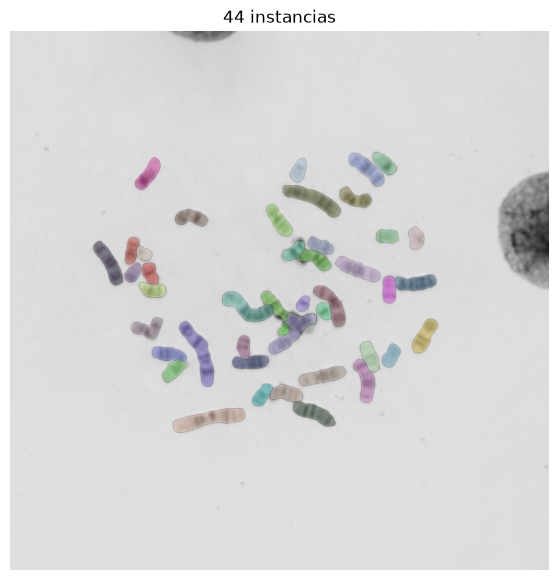

In [6]:
model, backend = segmentation.load_segmenter()
print("Backend:", backend)

result = segmentation.segment(model, backend, image, score_thresh=0.5)
print("Cromosomas detectados:", result.count)

plt.figure(figsize=(7, 7))
plt.imshow(result.overlay); plt.axis("off"); plt.title(str(result.count) + " instancias")
plt.show()

## Paso 2: extracción y registración

La función extract_chromosomes toma la imagen preprocesada y las máscaras, y devuelve un recorte de 224 x 224 por cada cromosoma. El procedimiento, para cada instancia, consta de tres pasos:

1. Recorte y aislamiento: se recorta el cromosoma según su máscara y se lo coloca sobre fondo blanco, descartando todo lo que quede fuera de la máscara.
2. Registración por PCA: se calcula el eje principal (la dirección de máxima varianza de los píxeles del cromosoma) y se rota el cromosoma a una orientación vertical canónica.
3. Escalado y centrado: todos los cromosomas de la imagen se escalan con un factor global común, preservando su tamaño relativo, y se centran en un lienzo de 224 x 224.

In [7]:
chromosomes = extraction.extract_chromosomes(clf_image, result.masks)
print("Cromosomas extraídos:", len(chromosomes))

Cromosomas extraídos: 44


### Detalle paso a paso sobre un cromosoma

Para ver qué hace la función internamente, reproducimos los pasos sobre un único cromosoma y mostramos cada resultado intermedio. El código que sigue es ilustrativo; en producción todo esto ocurre dentro de extract_chromosomes.

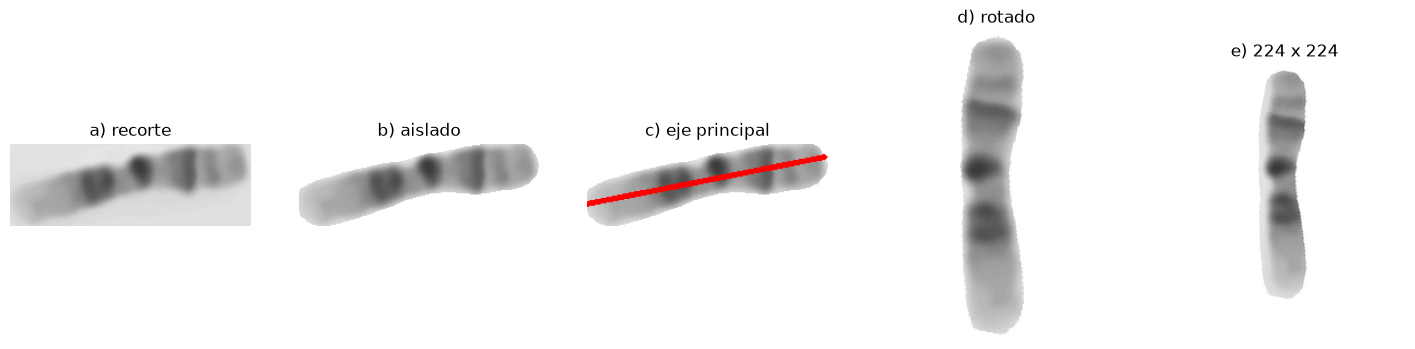

In [8]:
from PIL import Image

# Elegimos el cromosoma más grande para verlo con claridad.
idx = int(np.argmax([m.sum() for m in result.masks]))
mask = result.masks[idx]

# a) Recorte por bounding box de la máscara, sobre la imagen preprocesada.
ys, xs = np.where(mask)
y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
crop = clf_image[y0:y1 + 1, x0:x1 + 1]
crop_mask = mask[y0:y1 + 1, x0:x1 + 1]

# b) Aislamiento sobre fondo blanco.
isolated = np.where(crop_mask[:, :, None], crop, 255).astype(np.uint8)

# c) Eje principal (PCA), con la función canónica.
contour = extraction._largest_contour(mask.astype(np.uint8))
angle, length = extraction.compute_principal_axis(contour.astype(np.float64))

axis_vis = isolated.copy()
cx, cy = contour[:, 0].mean() - x0, contour[:, 1].mean() - y0
dx, dy = np.cos(angle), np.sin(angle)
p1 = (int(cx - dx * length / 2), int(cy - dy * length / 2))
p2 = (int(cx + dx * length / 2), int(cy + dy * length / 2))
cv2.line(axis_vis, p1, p2, (255, 0, 0), 3)

# d) Rotación a vertical (ángulo - 90 grados).
rotated = np.array(Image.fromarray(isolated).rotate(
    np.degrees(angle) - 90, expand=True, resample=Image.BICUBIC, fillcolor=(255, 255, 255)))

# e) Resultado final canónico (desde la función de producción, sobre esta única máscara).
final = np.array(extraction.extract_chromosomes(clf_image, mask[None, ...])[0].image)

panels = [(crop, "a) recorte"), (isolated, "b) aislado"),
          (axis_vis, "c) eje principal"), (rotated, "d) rotado"),
          (final, "e) 224 x 224")]
fig, ax = plt.subplots(1, 5, figsize=(18, 4))
for a, (im, t) in zip(ax, panels):
    a.imshow(im); a.set_title(t); a.axis("off")
plt.show()

## Resultado

Los recortes rectificados de 224 x 224, ordenados por tamaño. Cada uno de estos es una entrada para el clasificador.

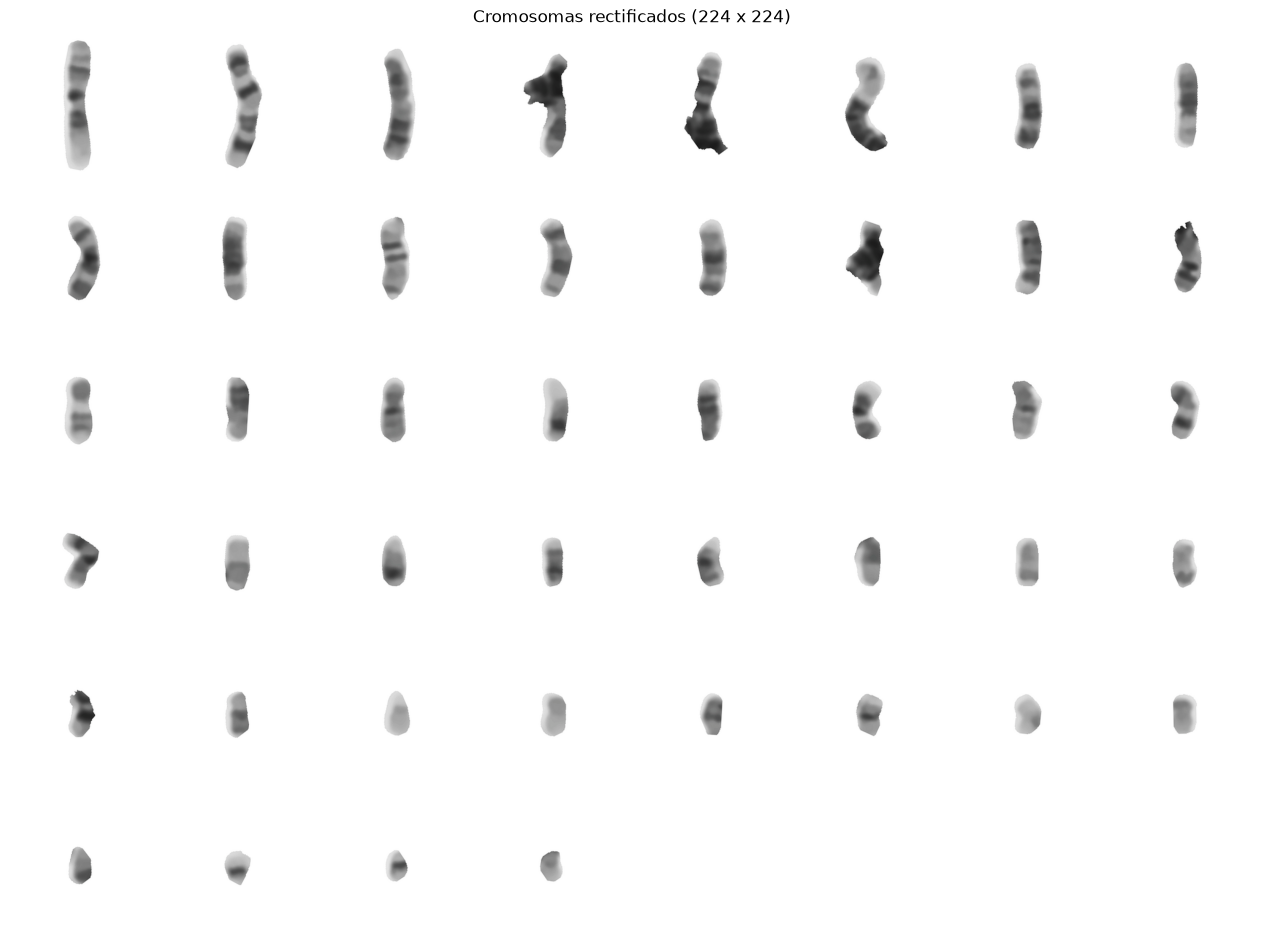

In [9]:
n = len(chromosomes)
cols = 8
rows = int(np.ceil(n / cols))
plt.figure(figsize=(cols * 1.6, rows * 1.6))
for i, ch in enumerate(sorted(chromosomes, key=lambda c: -c.length_px)):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(ch.image); plt.axis("off")
plt.suptitle("Cromosomas rectificados (224 x 224)")
plt.tight_layout()
plt.show()

## Cierre

Estos recortes son la entrada de la etapa de clasificación. Es fundamental que el preprocesamiento usado acá sea idéntico al usado para generar los recortes con los que se entrena el clasificador; de lo contrario se introduce un desajuste entre entrenamiento e inferencia que degrada la precisión.